# AI-Based Satellite Land-Use Classification and Environmental Change Detection

---

## Project Overview

This project uses deep learning to analyze satellite images and classify land-use types such as forests, residential areas, rivers, and crops.

The system also compares two satellite images taken at different times to detect environmental changes such as urban expansion or agricultural development.

A convolutional neural network (CNN) is trained on the EuroSAT dataset, and an AI-based transition analysis system is used to interpret land-use changes between two images.

---

## Key Features

- CNN-based satellite land-use classification.
- Comparison of multiple CNN models and architecture optimization.
- Detection of environmental land-use transitions between two images.
- Interpretation of transitions (e.g., urban expansion, agricultural growth).
- Confidence-based risk score estimation.
- Interactive interface for testing with dataset or uploaded images.
---


## Dataset

The project uses the **EuroSAT satellite image dataset**, which contains labeled satellite images for land-use classification.

Classes included in the dataset:

- AnnualCrop  
- Forest  
- HerbaceousVegetation  
- Highway  
- Industrial  
- Pasture  
- PermanentCrop  
- Residential  
- River  
- SeaLake  

Each image is a **64 × 64 satellite patch**.  
The dataset is divided into **training, validation, and testing sets** for model evaluation.

---

## Model Development

Two CNN models were developed for satellite image classification.

**Model A – Baseline CNN**
- Initial convolutional neural network architecture.
- Showed overfitting due to high parameter count.

**Model B – Optimized CNN**
- Reduced parameters
- Added dropout for regularization
- Applied data augmentation

Model B achieved better generalization and was used in the final system.

---

## Model Performance

| Model | Description | Parameters | Accuracy |
|------|-------------|------------|----------|
| Model A | Baseline CNN | ~6.9M | ~65% |
| Model B | Optimized CNN + Dropout | ~1.6M | ~78% |

Model B reduced model complexity and improved performance, so it was selected for the final system.

---

## Environmental Change Detection System

The trained CNN model is used to analyze two satellite images taken at different times and detect land-use transitions.

The system:

1. Classifies both satellite images.
2. Maps the predicted classes to broader land categories:
   - Natural
   - Agricultural
   - Built-Up
3. Detects transitions between categories.
4. Interprets environmental impact (e.g., urban expansion).
5. Calculates a confidence-based **risk score**.

Example:

Forest → Residential  
→ Detected transition: **Natural → Built-Up**  
→ Interpretation: **Urban Expansion**

---

## System Demonstration

The system analyzes two satellite images and detects land-use change between them.

It can be tested in two ways:

**1. Dataset Images**  
Two images from the EuroSAT dataset can be compared.

**2. Uploaded Images**  
Users can upload their own before-and-after satellite images using the interactive interface.

The system then:
- Classifies both images using the CNN model
- Detects land-use transition
- Interprets environmental impact
- Calculates a confidence-based risk score

Example:

Forest → Residential  
Detected Transition: **Natural → Built-Up**  
Interpretation: **Urban Expansion**

---

## How to Use This System

The system can be tested in two ways:

### 1. Using Dataset Images
Select two images from the EuroSAT dataset and run the change detection function to compare their predicted land-use classes.

### 2. Using Uploaded Images
Upload two satellite images (before and after) using the interactive upload interface.

### Running the Analysis
1. Run the notebook cells to load libraries and the trained model.
2. Upload or select two satellite images.
3. Click **Run AI Change Analysis**.
4. The system will classify both images, detect land-use transitions, and display the interpretation with a risk score.
___


In [2]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
!nvidia-smi


Sun Mar  8 14:36:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!wget http://madm.dfki.de/files/sentinel/EuroSAT.zip
!unzip EuroSAT.zip


--2026-03-08 14:36:27--  http://madm.dfki.de/files/sentinel/EuroSAT.zip
Resolving madm.dfki.de (madm.dfki.de)... 131.246.195.183
Connecting to madm.dfki.de (madm.dfki.de)|131.246.195.183|:80... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-03-08 14:36:27 ERROR 403: Forbidden.

unzip:  cannot find or open EuroSAT.zip, EuroSAT.zip.zip or EuroSAT.zip.ZIP.


In [5]:
!pip install tensorflow-datasets


In [6]:
import os
os.environ['KAGGLE_USERNAME'] = 'Aanya Agrahari'
os.environ['KAGGLE_KEY'] = 'KGAT_c77f77f6cc1edbca5318fb23ea41cfcd'


In [7]:
!pip install kaggle


In [8]:
!kaggle datasets download -d apollo2506/eurosat-dataset


Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
 99% 2.02G/2.04G [00:16<00:00, 140MB/s]
100% 2.04G/2.04G [00:20<00:00, 108MB/s]


In [9]:
!unzip eurosat-dataset.zip


Streaming output truncated to the last 5000 lines.
  inflating: EuroSATallBands/River/River_1990.tif  
  inflating: EuroSATallBands/River/River_1991.tif  
  inflating: EuroSATallBands/River/River_1992.tif  
  inflating: EuroSATallBands/River/River_1993.tif  
  inflating: EuroSATallBands/River/River_1994.tif  
  inflating: EuroSATallBands/River/River_1995.tif  
  inflating: EuroSATallBands/River/River_1996.tif  
  inflating: EuroSATallBands/River/River_1997.tif  
  inflating: EuroSATallBands/River/River_1998.tif  
  inflating: EuroSATallBands/River/River_1999.tif  
  inflating: EuroSATallBands/River/River_2.tif  
  inflating: EuroSATallBands/River/River_20.tif  
  inflating: EuroSATallBands/River/River_200.tif  
  inflating: EuroSATallBands/River/River_2000.tif  
  inflating: EuroSATallBands/River/River_2001.tif  
  inflating: EuroSATallBands/River/River_2002.tif  
  inflating: EuroSATallBands/River/River_2003.tif  
  inflating: EuroSATallBands/River/River_2004.tif  
  inflating: EuroSA

In [10]:
!ls


after.jpg   EuroSAT	     eurosat-dataset.zip  highway.jpg	sample_data
before.jpg  EuroSATallBands  forest.jpg		  industry.jpg


In [11]:
import os

data_path = "/content/EuroSAT"

classes = os.listdir(data_path)
print("Classes:", classes)
print("Total Classes:", len(classes))


Classes: ['SeaLake', 'River', 'Highway', 'PermanentCrop', 'Forest', 'test.csv', 'AnnualCrop', 'train.csv', 'label_map.json', 'validation.csv', 'Pasture', 'HerbaceousVegetation', 'Industrial', 'Residential']
Total Classes: 14


In [12]:
for cls in classes:
    print(cls)


SeaLake
River
Highway
PermanentCrop
Forest
test.csv
AnnualCrop
train.csv
label_map.json
validation.csv
Pasture
HerbaceousVegetation
Industrial
Residential


In [13]:
import os

data_path = "/content/EuroSAT"

all_items = os.listdir(data_path)

classes = [item for item in all_items
           if os.path.isdir(os.path.join(data_path, item))]

print("Filtered Classes:", classes)
print("Total Image Classes:", len(classes))


Filtered Classes: ['SeaLake', 'River', 'Highway', 'PermanentCrop', 'Forest', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Industrial', 'Residential']
Total Image Classes: 10


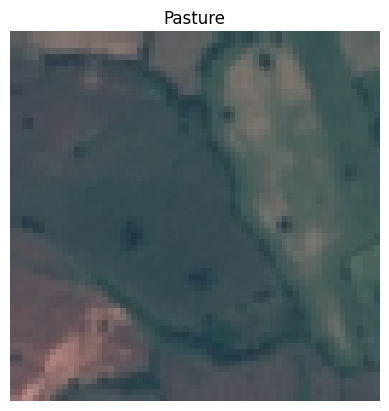

In [14]:
import random
import matplotlib.pyplot as plt

# choose random class
sample_class = random.choice(classes)

# choose random image inside that class
sample_image = random.choice(os.listdir(os.path.join(data_path, sample_class)))

img_path = os.path.join(data_path, sample_class, sample_image)

img = plt.imread(img_path)

plt.imshow(img)
plt.title(sample_class)
plt.axis("off")
plt.show()


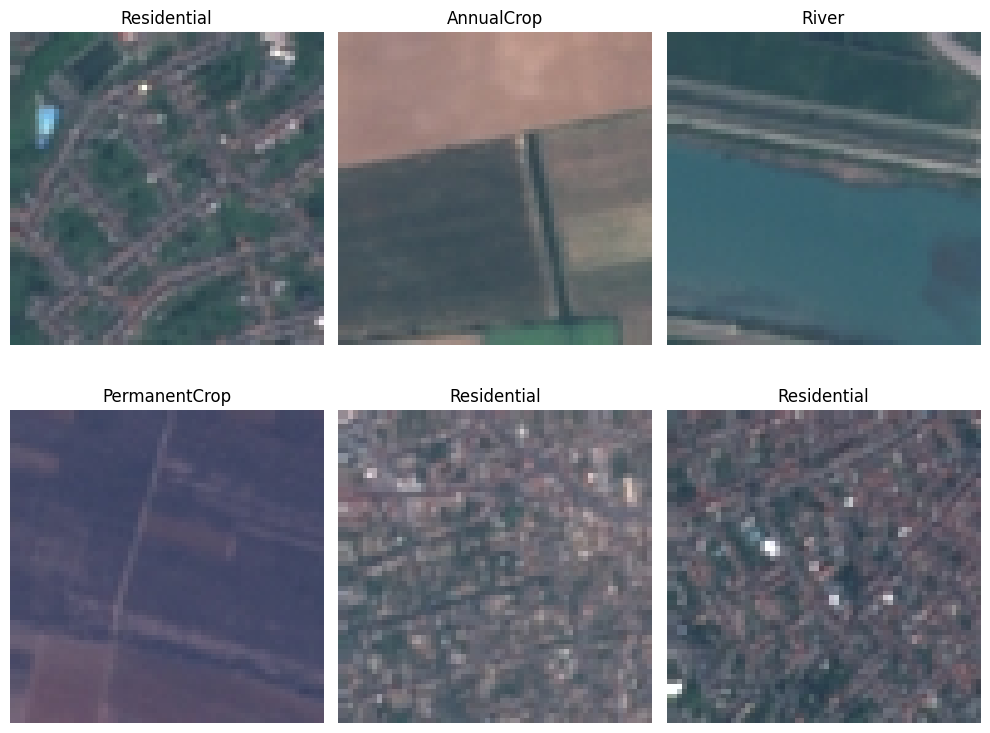

In [15]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(10,8))

for i in range(6):
    sample_class = random.choice(classes)
    sample_image = random.choice(os.listdir(os.path.join(data_path, sample_class)))
    img_path = os.path.join(data_path, sample_class, sample_image)
    img = plt.imread(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(sample_class)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [16]:
import os

# Create project folders
os.makedirs("/content/ISRO_Project/models", exist_ok=True)
os.makedirs("/content/ISRO_Project/results", exist_ok=True)
os.makedirs("/content/ISRO_Project/notebooks", exist_ok=True)

print("Project folders created successfully!")


Project folders created successfully!


In [17]:
total_images = 0

for cls in classes:
    total_images += len(os.listdir(os.path.join(data_path, cls)))

print("Total images:", total_images)


Total images: 27000


In [18]:
print("Image shape:", img.shape)


Image shape: (64, 64, 3)


In [19]:
!ls


after.jpg   EuroSAT	     eurosat-dataset.zip  highway.jpg	ISRO_Project
before.jpg  EuroSATallBands  forest.jpg		  industry.jpg	sample_data


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [21]:
datagen = ImageDataGenerator(
    rescale=1./255,      # normalize pixel values (0–255 → 0–1)
    validation_split=0.2 # 20% for validation
)
train_generator = datagen.flow_from_directory(
    "/content/EuroSAT",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)


Found 21600 images belonging to 10 classes.


In [22]:
validation_generator = datagen.flow_from_directory(
    "/content/EuroSAT",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)


Found 5400 images belonging to 10 classes.
Image batch shape: (32, 64, 64, 3)
Label batch shape: (32, 10)


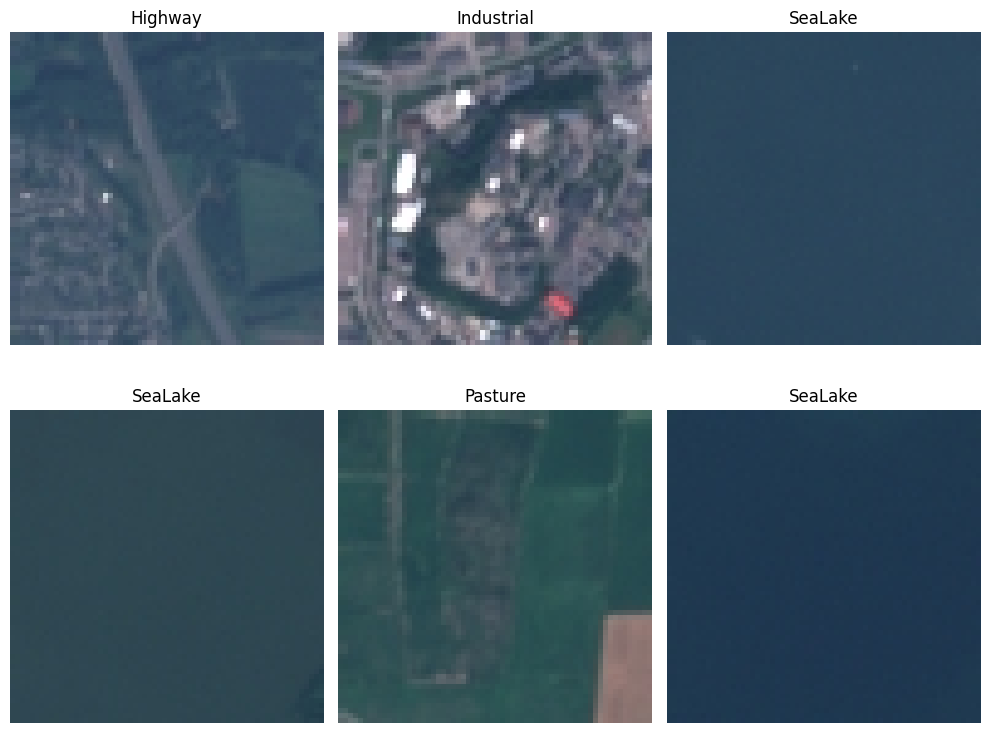

In [23]:
import matplotlib.pyplot as plt
import numpy as np

class_names = train_generator.class_indices
class_names = {v: k for k, v in class_names.items()}

plt.figure(figsize=(10,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    label_index = np.argmax(labels[i])
    plt.title(class_names[label_index])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [25]:
model = Sequential()


In [26]:
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(64,64,3)
))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.add(MaxPooling2D(pool_size=(2,2)))


In [28]:
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))


In [29]:
model.add(Flatten())


In [30]:
model.add(Dense(128, activation='relu'))


In [31]:
model.add(Dense(10, activation='softmax'))


In [32]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [33]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 53824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,889,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,910,282 (26.36 MB)

 Trainable params: 6,910,282 (26.36 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=3
)


Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


675/675 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.4310 - loss: 1.5450 - val_accuracy: 0.7017 - val_loss: 0.8145
Epoch 2/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.7160 - loss: 0.7794 - val_accuracy: 0.7380 - val_loss: 0.7478
Epoch 3/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7891 - loss: 0.5866 - val_accuracy: 0.7681 - val_loss: 0.6487


In [35]:
from tensorflow.keras.layers import Dropout

model_b = Sequential()


In [36]:
model_b.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(64,64,3)
))

model_b.add(MaxPooling2D(pool_size=(2,2)))


In [37]:
model_b.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

model_b.add(MaxPooling2D(pool_size=(2,2)))


In [38]:
model_b.add(Flatten())

model_b.add(Dense(128, activation='relu'))

model_b.add(Dropout(0.5))


In [39]:
model_b.add(Dense(10, activation='softmax'))


In [40]:
model_b.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [41]:
model_b.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [87]:
model_path = "land_use_model.keras"

if os.path.exists(model_path):
    print("Saved model found. Loading model...")
    model_b = load_model(model_path)

else:
    print("No saved model found. Training model...")

Saved model found. Loading model...


In [42]:
history_b = model_b.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=3
)


Epoch 1/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.3203 - loss: 1.7705 - val_accuracy: 0.6044 - val_loss: 1.1322
Epoch 2/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.5484 - loss: 1.2248 - val_accuracy: 0.6613 - val_loss: 0.9495
Epoch 3/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6157 - loss: 1.0449 - val_accuracy: 0.7435 - val_loss: 0.7452


In [43]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    initial_epoch=3
)


Epoch 4/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8193 - loss: 0.5044 - val_accuracy: 0.7498 - val_loss: 0.7022
Epoch 5/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8512 - loss: 0.4087 - val_accuracy: 0.7848 - val_loss: 0.6403


In [88]:
history_b = model_b.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    initial_epoch=3
)
model_b.save("land_use_model.keras")
print("Model saved.")


Epoch 4/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.7761 - loss: 0.6332 - val_accuracy: 0.7944 - val_loss: 0.5882
Epoch 5/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7979 - loss: 0.5787 - val_accuracy: 0.8309 - val_loss: 0.4900
Model saved.


### Models Accuracy Graph

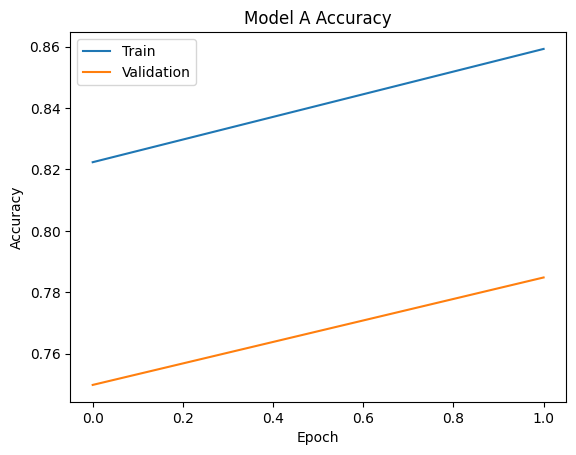

In [45]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model A Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()


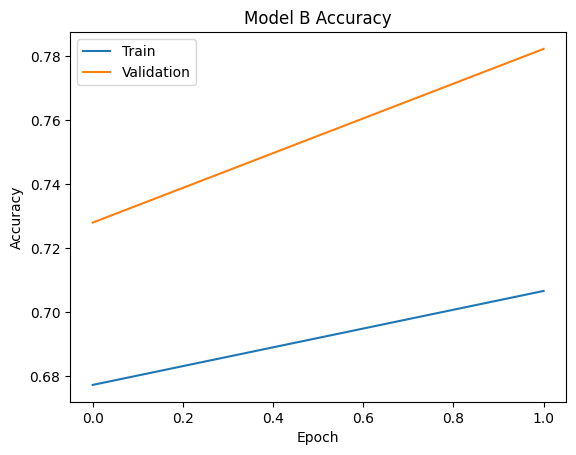

In [46]:
plt.plot(history_b.history['accuracy'])
plt.plot(history_b.history['val_accuracy'])
plt.title('Model B Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()


In [47]:
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [48]:
model_b.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,879,328 (18.61 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,252,886 (12.41 MB)

In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [50]:
train_generator_aug = augmented_datagen.flow_from_directory(
    "/content/EuroSAT",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator_aug = augmented_datagen.flow_from_directory(
    "/content/EuroSAT",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


In [ ]:
history_b_aug = model_b.fit(
    train_generator_aug,
    validation_data=validation_generator_aug,
    epochs=5
)

Epoch 1/5
637/675 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7108 - loss: 0.8239

In [ ]:
plt.plot(history_b_aug.history['accuracy'])
plt.plot(history_b_aug.history['val_accuracy'])
plt.title('Model B (Augmented) Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
import numpy as np

# Get true labels
y_true = validation_generator_aug.classes

# Predict
y_pred_probs = model_b.predict(validation_generator_aug)
y_pred = np.argmax(y_pred_probs, axis=1)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix - Model B (Augmented)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
class_indices = validation_generator_aug.class_indices
class_names = list(class_indices.keys())

print(class_names)

In [ ]:
import numpy as np

# Get indices of largest off-diagonal confusions
cm_copy = cm.copy()

# Remove diagonal
np.fill_diagonal(cm_copy, 0)

# Find top 5 largest confusion values
flat_indices = np.argsort(cm_copy, axis=None)[-5:]

for idx in flat_indices:
    i, j = np.unravel_index(idx, cm_copy.shape)
    print(f"Actual: {class_names[i]} → Predicted: {class_names[j]} | Count: {cm_copy[i][j]}")

In [ ]:
for i in range(len(class_names)):
    class_accuracy = cm[i][i] / np.sum(cm[i])
    print(f"{class_names[i]} Accuracy: {class_accuracy:.2f}")

In [ ]:
import random
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Pick random class
random_class = random.choice(class_names)

# Pick random image from that class
class_path = os.path.join("/content/EuroSAT", random_class)
random_image = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, random_image)

print("Actual Class:", random_class)

# Load image
img = image.load_img(img_path, target_size=(64, 64))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model_b.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

# Show image
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
for _ in range(10):
    random_class = random.choice(class_names)
    class_path = os.path.join("/content/EuroSAT", random_class)
    random_image = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_image)

    img = image.load_img(img_path, target_size=(64, 64))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model_b.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]

    print(f"Actual: {random_class} | Predicted: {predicted_class}")

In [ ]:
model_b.save("model_b.keras")

In [ ]:
from tensorflow.keras.models import load_model

model_b = load_model("model_b.keras")
print("Model loaded successfully")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load image
img = image.load_img("forest.jpg", target_size=(64, 64))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model_b.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

# Show image
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
img = image.load_img("industry.jpg", target_size=(64, 64))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model_b.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

prediction = model_b.predict(img_array)

for i, prob in enumerate(prediction[0]):
    print(f"{class_names[i]} : {prob:.4f}")

In [ ]:
img = image.load_img("highway.jpg", target_size=(64, 64))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model_b.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

for i, prob in enumerate(prediction[0]):
    print(f"{class_names[i]} : {prob:.4f}")

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
test_loss, test_acc = model_b.evaluate(test_generator)
print("Test Accuracy:", test_acc)

In [67]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

test_generator = datagen.flow_from_directory(
    "/content/EuroSAT",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 27000 images belonging to 10 classes.


In [68]:
test_loss, test_acc = model_b.evaluate(test_generator)
print("Test Accuracy:", test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.7767 - loss: 0.6737
Test Accuracy: 0.7841851711273193


In [69]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(64, 64))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model_b.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    return predicted_class, confidence, img


def detect_change(img1_path, img2_path):

    class1, conf1, img1 = predict_image(img1_path)
    class2, conf2, img2 = predict_image(img2_path)

    print("🛰 SATELLITE LAND-USE CHANGE DETECTION SYSTEM")
    print("--------------------------------------------------")
    print(f"Image A Prediction: {class1} ({conf1*100:.2f}%)")
    print(f"Image B Prediction: {class2} ({conf2*100:.2f}%)")
    print("--------------------------------------------------")

    if class1 == class2:
        print("✅ No major land-use change detected.")
    else:
        print("⚠ Land-use change detected!")

        if class1 == "Forest" and class2 == "Residential":
            print("🌆 Possible Urban Expansion Detected.")
        elif class1 == "Forest" and class2 == "AnnualCrop":
            print("🌾 Possible Agricultural Expansion Detected.")
        elif class1 == "Residential" and class2 == "Industrial":
            print("🏭 Possible Industrial Development.")
        else:
            print("🔎 Change observed between land-use categories.")

    print("--------------------------------------------------")

    # Display images side by side
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title("Before")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.title("After")
    plt.axis("off")

    plt.show()

🛰 SATELLITE LAND-USE CHANGE DETECTION SYSTEM
--------------------------------------------------
Image A Prediction: Pasture (79.56%)
Image B Prediction: Industrial (74.88%)
--------------------------------------------------
⚠ Land-use change detected!
🔎 Change observed between land-use categories.
--------------------------------------------------


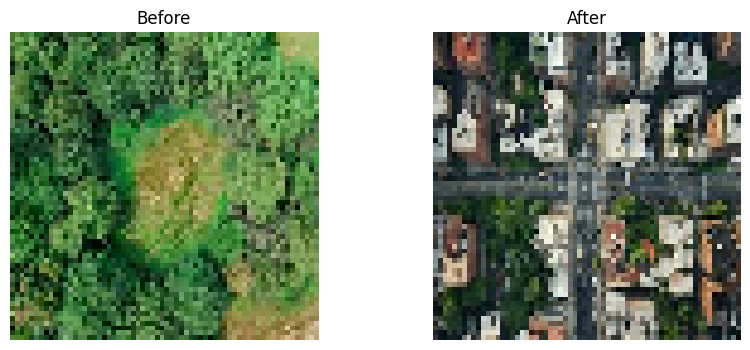

In [70]:
detect_change("before.jpg", "after.jpg")

In [71]:
land_categories = {
    "Forest": "Natural",
    "River": "Natural",
    "SeaLake": "Natural",
    "HerbaceousVegetation": "Natural",
    "Pasture": "Natural",

    "AnnualCrop": "Agricultural",
    "PermanentCrop": "Agricultural",

    "Residential": "Built-Up",
    "Industrial": "Built-Up",
    "Highway": "Built-Up"
}

In [72]:
def detect_change_advanced(img1_path, img2_path):

    class1, conf1, img1 = predict_image(img1_path)
    class2, conf2, img2 = predict_image(img2_path)

    category1 = land_categories[class1]
    category2 = land_categories[class2]

    confidence_delta = abs(conf2 - conf1)
    risk_score = (conf1 + conf2) / 2

    print("🛰 AI-DRIVEN LAND-USE TRANSITION ANALYSIS SYSTEM")
    print("--------------------------------------------------")
    print(f"Image A: {class1} ({conf1*100:.2f}%) → Category: {category1}")
    print(f"Image B: {class2} ({conf2*100:.2f}%) → Category: {category2}")
    print("--------------------------------------------------")

    if class1 == class2:
        print("✅ No major land-use change detected.")
        impact = "Stable"
    else:
        print(f"⚠ Detected Transition: {category1} → {category2}")

        if category1 == "Natural" and category2 == "Built-Up":
            interpretation = "Urban / Infrastructure Expansion"
        elif category1 == "Natural" and category2 == "Agricultural":
            interpretation = "Agricultural Expansion"
        elif category1 == "Agricultural" and category2 == "Built-Up":
            interpretation = "Urban Encroachment on Agricultural Land"
        elif category1 == "Built-Up" and category2 == "Natural":
            interpretation = "Possible Land Restoration / Reforestation"
        else:
            interpretation = "Land-Use Structural Shift"

        print(f"🌍 Interpretation: {interpretation}")

        if risk_score > 0.85:
            impact = "High Impact"
        elif risk_score > 0.65:
            impact = "Moderate Impact"
        else:
            impact = "Low Confidence Shift"

        print(f"📊 Risk Score: {risk_score:.2f}")
        print(f"🚨 Impact Level: {impact}")

    print("--------------------------------------------------")

    # Display images side by side
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title("Before")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.title("After")
    plt.axis("off")

    plt.show()

🛰 AI-DRIVEN LAND-USE TRANSITION ANALYSIS SYSTEM
--------------------------------------------------
Image A: Pasture (79.56%) → Category: Natural
Image B: Industrial (74.88%) → Category: Built-Up
--------------------------------------------------
⚠ Detected Transition: Natural → Built-Up
🌍 Interpretation: Urban / Infrastructure Expansion
📊 Risk Score: 0.77
🚨 Impact Level: Moderate Impact
--------------------------------------------------


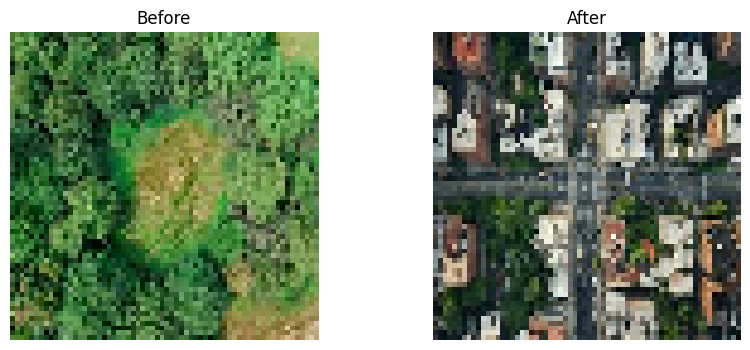

In [73]:
detect_change_advanced("before.jpg", "after.jpg")

🛰 AI-DRIVEN LAND-USE TRANSITION ANALYSIS SYSTEM
--------------------------------------------------
Image A: Industrial (74.88%) → Category: Built-Up
Image B: Pasture (79.56%) → Category: Natural
--------------------------------------------------
⚠ Detected Transition: Built-Up → Natural
🌍 Interpretation: Possible Land Restoration / Reforestation
📊 Risk Score: 0.77
🚨 Impact Level: Moderate Impact
--------------------------------------------------


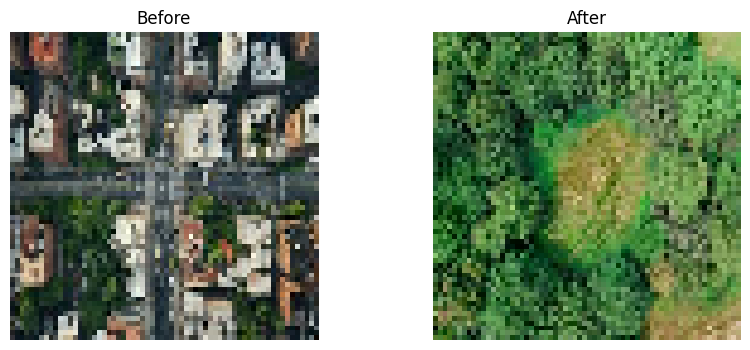

In [74]:
detect_change_advanced("after.jpg", "before.jpg")

In [75]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(64, 64))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model_b.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    return predicted_class, confidence, prediction[0], img

In [76]:
def detect_change_advanced(img1_path, img2_path):

    class1, conf1, probs1, img1 = predict_image(img1_path)
    class2, conf2, probs2, img2 = predict_image(img2_path)

    category1 = land_categories[class1]
    category2 = land_categories[class2]

    risk_score = (conf1 + conf2) / 2

    print("🛰 AI-DRIVEN LAND-USE TRANSITION ANALYSIS SYSTEM")
    print("--------------------------------------------------")
    print(f"Image A: {class1} ({conf1*100:.2f}%) → Category: {category1}")
    print(f"Image B: {class2} ({conf2*100:.2f}%) → Category: {category2}")
    print("--------------------------------------------------")

    if class1 == class2:
        print("✅ No major land-use change detected.")
        impact = "Stable"
    else:
        print(f"⚠ Detected Transition: {category1} → {category2}")

        if category1 == "Natural" and category2 == "Built-Up":
            interpretation = "Urban / Infrastructure Expansion"
        elif category1 == "Natural" and category2 == "Agricultural":
            interpretation = "Agricultural Expansion"
        elif category1 == "Agricultural" and category2 == "Built-Up":
            interpretation = "Urban Encroachment on Agricultural Land"
        elif category1 == "Built-Up" and category2 == "Natural":
            interpretation = "Possible Land Restoration / Reforestation"
        else:
            interpretation = "Land-Use Structural Shift"

        print(f"🌍 Interpretation: {interpretation}")

        if risk_score > 0.85:
            impact = "High Impact"
        elif risk_score > 0.65:
            impact = "Moderate Impact"
        else:
            impact = "Low Confidence Shift"

        print(f"📊 Risk Score: {risk_score:.2f}")
        print(f"🚨 Impact Level: {impact}")

    print("--------------------------------------------------")

    # Show images
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(img1)
    plt.title("Before")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(img2)
    plt.title("After")
    plt.axis("off")

    # Bar chart comparison
    plt.subplot(1,3,3)
    x = np.arange(len(class_names))
    width = 0.35
    plt.bar(x - width/2, probs1, width, label="Before")
    plt.bar(x + width/2, probs2, width, label="After")
    plt.xticks(x, class_names, rotation=90)
    plt.title("Confidence Comparison")
    plt.legend()

    plt.tight_layout()
    plt.show()

🛰 AI-DRIVEN LAND-USE TRANSITION ANALYSIS SYSTEM
--------------------------------------------------
Image A: Pasture (79.56%) → Category: Natural
Image B: Industrial (74.88%) → Category: Built-Up
--------------------------------------------------
⚠ Detected Transition: Natural → Built-Up
🌍 Interpretation: Urban / Infrastructure Expansion
📊 Risk Score: 0.77
🚨 Impact Level: Moderate Impact
--------------------------------------------------


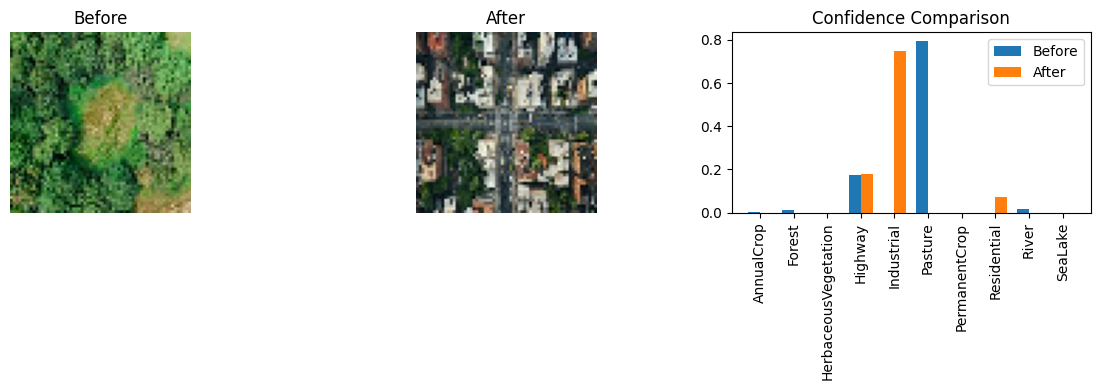

In [77]:
detect_change_advanced("before.jpg", "after.jpg")

# Quick Demo

This section allows users to test the trained AI system.

Users can upload two satellite images (before and after) or use dataset images to analyze land-use changes.

---


In [78]:
import ipywidgets as widgets
from IPython.display import display

## Upload Images for Analysis

In [79]:
upload_before = widgets.FileUpload(accept='image/*', multiple=False)
upload_after = widgets.FileUpload(accept='image/*', multiple=False)

display(widgets.HTML("<h3>Upload Before Image</h3>"))
display(upload_before)

display(widgets.HTML("<h3>Upload After Image</h3>"))
display(upload_after)

HTML(value='<h3>Upload Before Image</h3>')

FileUpload(value={}, accept='image/*', description='Upload')

HTML(value='<h3>Upload After Image</h3>')

FileUpload(value={}, accept='image/*', description='Upload')

## Run AI Change Analysis

Button(button_style='success', description='Run AI Change Analysis', style=ButtonStyle())

🛰 AI-DRIVEN LAND-USE TRANSITION ANALYSIS SYSTEM
--------------------------------------------------
Image A: Pasture (95.73%) → Category: Natural
Image B: Industrial (99.94%) → Category: Built-Up
--------------------------------------------------
⚠ Detected Transition: Natural → Built-Up
🌍 Interpretation: Urban / Infrastructure Expansion
📊 Risk Score: 0.98
🚨 Impact Level: High Impact
--------------------------------------------------


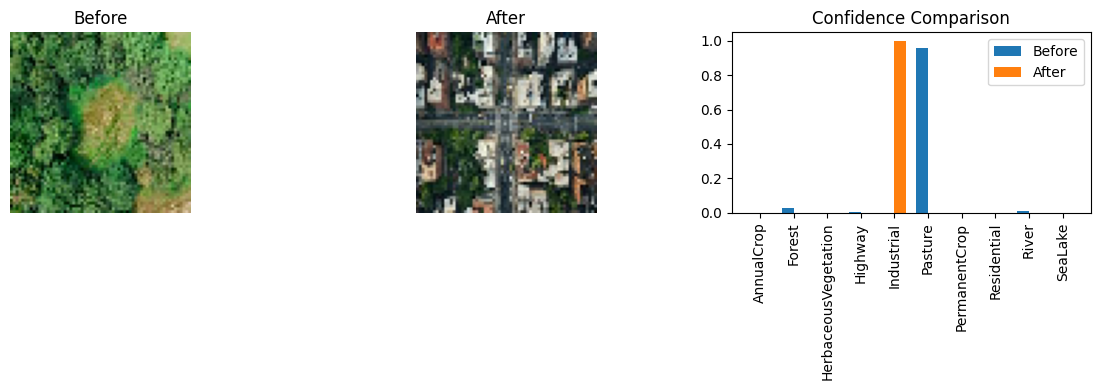

In [80]:
run_button = widgets.Button(description="Run AI Change Analysis", button_style='success')
display(run_button)

In [81]:
import io

def on_button_click(b):

    if not upload_before.value or not upload_after.value:
        print("⚠ Please upload both images first.")
        return

    # Get uploaded files
    before_filename = list(upload_before.value.keys())[0]
    after_filename = list(upload_after.value.keys())[0]

    before_content = upload_before.value[before_filename]['content']
    after_content = upload_after.value[after_filename]['content']

    # Save files temporarily
    with open("temp_before.jpg", "wb") as f:
        f.write(before_content)

    with open("temp_after.jpg", "wb") as f:
        f.write(after_content)

    # Run advanced detection
    detect_change_advanced("temp_before.jpg", "temp_after.jpg")

run_button.on_click(on_button_click)

In [85]:
import os
os.listdir()

['.config',
 'EuroSATallBands',
 'after.jpg',
 'eurosat-dataset.zip',
 'ISRO_Project',
 'model_b.keras',
 '.ipynb_checkpoints',
 'before.jpg',
 'highway.jpg',
 'land_use_model.keras',
 'EuroSAT',
 'industry.jpg',
 'forest.jpg',
 'sample_data']